In [3]:
import pandas as pd
df = pd.read_csv('../data/creditcard.csv')
print(df.shape)
print(df.head())
df.info()
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True))

(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

In [4]:
print(df[['Time', 'Amount']].describe())

                Time         Amount
count  284807.000000  284807.000000
mean    94813.859575      88.349619
std     47488.145955     250.120109
min         0.000000       0.000000
25%     54201.500000       5.600000
50%     84692.000000      22.000000
75%    139320.500000      77.165000
max    172792.000000   25691.160000


In [5]:
X = df.drop('Class', axis=1)
y = df['Class']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(y_train.value_counts())
print(y_test.value_counts())
print(y_train.value_counts(normalize=True))

Class
0    227451
1       394
Name: count, dtype: int64
Class
0    56864
1       98
Name: count, dtype: int64
Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64


In [14]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test_scaled[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])
print(X_train_scaled[['Time', 'Amount']].describe())


                Time         Amount
count  227845.000000  227845.000000
mean        0.118400       0.921034
std         0.557795       3.489528
min        -0.996112      -0.306193
25%        -0.359155      -0.227697
50%         0.000000       0.000000
75%         0.640845       0.772303
max         1.033488     357.260404


In [15]:
import json
row = X_test.iloc[1].to_dict()
print(json.dumps(row, indent=2))

{
  "Time": 19847.0,
  "V1": -2.82981594327279,
  "V2": -2.76514921229269,
  "V3": 2.53779295063997,
  "V4": -1.07458042259191,
  "V5": 2.84255889292598,
  "V6": -2.15353644367205,
  "V7": -1.79551885720369,
  "V8": -0.250020372324704,
  "V9": 3.07350426338358,
  "V10": -1.00041794567463,
  "V11": 1.85084176033081,
  "V12": -1.54977887088034,
  "V13": 1.25233673695303,
  "V14": 0.963974373307274,
  "V15": -0.481027223791626,
  "V16": -0.14731917203129,
  "V17": -0.209328171581066,
  "V18": 1.05889790297841,
  "V19": 0.397056508186649,
  "V20": -0.515764693656115,
  "V21": -0.295554564490287,
  "V22": 0.109304966698836,
  "V23": -0.81327196874425,
  "V24": 0.0429955726118499,
  "V25": -0.0276596849389052,
  "V26": -0.910247054904536,
  "V27": 0.110801759066737,
  "V28": -0.511938134872381,
  "Amount": 11.85
}


In [16]:
print(y_test.iloc[1])

0


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, average_precision_score, precision_recall_curve

baseline_model = LogisticRegression(class_weight='balanced', max_iter=1000)
baseline_model.fit(X_train_scaled, y_train)

y_pred = baseline_model.predict(X_test_scaled)
y_proba = baseline_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print("Average Precision (AUPRC):", average_precision_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

Average Precision (AUPRC): 0.7174539341990155


In [8]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(y_train_smote.value_counts())

Class
0    227451
1    227451
Name: count, dtype: int64


In [9]:
smote_model = LogisticRegression(max_iter=1000)
smote_model.fit(X_train_smote, y_train_smote)

y_pred_smote = smote_model.predict(X_test_scaled)
y_proba_smote = smote_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_smote))
print("Average Precision (AUPRC):", average_precision_score(y_test, y_proba_smote))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

Average Precision (AUPRC): 0.7250575063969292


In [10]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination=0.0017, random_state=42)
iso_forest.fit(X_train_scaled)

# Isolation Forest outputs -1 for anomaly, 1 for normal — convert to match Class (1=fraud, 0=normal)
y_pred_iso = iso_forest.predict(X_test_scaled)
y_pred_iso = [1 if x == -1 else 0 for x in y_pred_iso]

print(classification_report(y_test, y_pred_iso))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.31      0.34      0.32        98

    accuracy                           1.00     56962
   macro avg       0.66      0.67      0.66     56962
weighted avg       1.00      1.00      1.00     56962



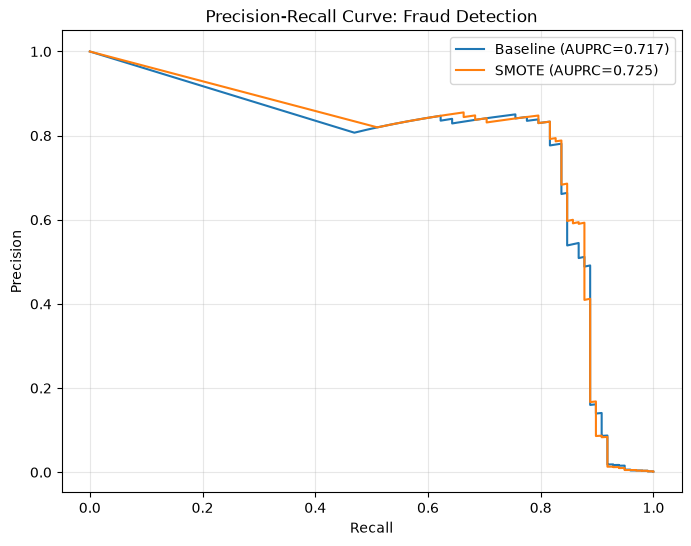

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Get precision/recall pairs across all thresholds for each model
precision_base, recall_base, _ = precision_recall_curve(y_test, y_proba)
precision_smote, recall_smote, _ = precision_recall_curve(y_test, y_proba_smote)

plt.figure(figsize=(8, 6))
plt.plot(recall_base, precision_base, label=f'Baseline (AUPRC={average_precision_score(y_test, y_proba):.3f})')
plt.plot(recall_smote, precision_smote, label=f'SMOTE (AUPRC={average_precision_score(y_test, y_proba_smote):.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve: Fraud Detection')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('../docs/pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
precision_base, recall_base, thresholds_base = precision_recall_curve(y_test, y_proba)

# Find the point closest to recall = 0.8 (the "knee" we discussed)
import numpy as np
# Only search within valid threshold range (exclude the last synthetic point)
valid_range = len(thresholds_base)

idx = np.argmin(np.abs(recall_base[:valid_range] - 0.8))

print(f"At recall={recall_base[idx]:.3f}, precision={precision_base[idx]:.3f}")
print(f"Threshold: {thresholds_base[idx]:.10f}")

At recall=0.796, precision=0.830
Threshold: 0.9999999896


In [13]:
import joblib

joblib.dump(baseline_model, '../src/fraud_model.pkl')
joblib.dump(scaler, '../src/scaler.pkl')

['../src/scaler.pkl']